# Laboratorio 10 - Búsqueda Eficiente con PgVector

## P0 a P2: Carga del dataset, generación de embeddings y búsqueda kNN lineal

Este notebook desarrolla:

- **P0:** Cargar el dataset de rostros LFW.
- **P1:** Generar embeddings faciales de 128 dimensiones con `face_recognition`.
- **P2:** Realizar búsqueda kNN lineal usando distancia euclidiana `<->` y distancia coseno `<=>`.


## Requisitos previos

Antes de ejecutar este notebook, asegúrate de haber creado el entorno Conda:

```bash
conda create -n vision python=3.9
conda activate vision
conda install -c conda-forge dlib
conda install -c conda-forge face_recognition
pip install pandas numpy matplotlib psycopg2-binary pgvector jupyter
```

Además, el contenedor de PostgreSQL con pgvector debe estar activo:

```bash
docker start pgvector
```

Si todavía no existe el contenedor:

```bash
docker run -d --name pgvector -e POSTGRES_PASSWORD=123456 -p 5433:5432 ankane/pgvector
```


# P0. Cargar el Dataset de Rostros

La ruta del dataset debe apuntar a la carpeta que contiene las subcarpetas de personas.

En tu caso, la ruta es:

```text
C:\Users\josue\Downloads\archive (1)\lfw-funneled\lfw_funneled
```


In [1]:
import os
import glob
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Ruta del dataset LFW
DATASET_PATH = r"C:\Users\josue\Downloads\archive (1)\lfw-funneled\lfw_funneled"


In [2]:
def cargar_coleccion(dataset_path):
    """
    Carga todas las imágenes .jpg del dataset LFW.
    Retorna un DataFrame con columnas: person y path.
    """
    coleccion = []

    for path in glob.iglob(os.path.join(dataset_path, "**", "*.jpg"), recursive=True):
        person = Path(path).parent.name
        coleccion.append({
            "person": person,
            "path": path
        })

    return pd.DataFrame(coleccion)


coleccion = cargar_coleccion(DATASET_PATH)

print("Cantidad de imágenes cargadas:", len(coleccion))
coleccion.head(10)


Cantidad de imágenes cargadas: 13233


,person,path
0,Aaron_Eckhart,C:\Users\josue\Downloads\archive (1)\lfw-funne...
1,Aaron_Guiel,C:\Users\josue\Downloads\archive (1)\lfw-funne...
2,Aaron_Patterson,C:\Users\josue\Downloads\archive (1)\lfw-funne...
3,Aaron_Peirsol,C:\Users\josue\Downloads\archive (1)\lfw-funne...
4,Aaron_Peirsol,C:\Users\josue\Downloads\archive (1)\lfw-funne...
5,Aaron_Peirsol,C:\Users\josue\Downloads\archive (1)\lfw-funne...
6,Aaron_Peirsol,C:\Users\josue\Downloads\archive (1)\lfw-funne...
7,Aaron_Pena,C:\Users\josue\Downloads\archive (1)\lfw-funne...
8,Aaron_Sorkin,C:\Users\josue\Downloads\archive (1)\lfw-funne...
9,Aaron_Sorkin,C:\Users\josue\Downloads\archive (1)\lfw-funne...


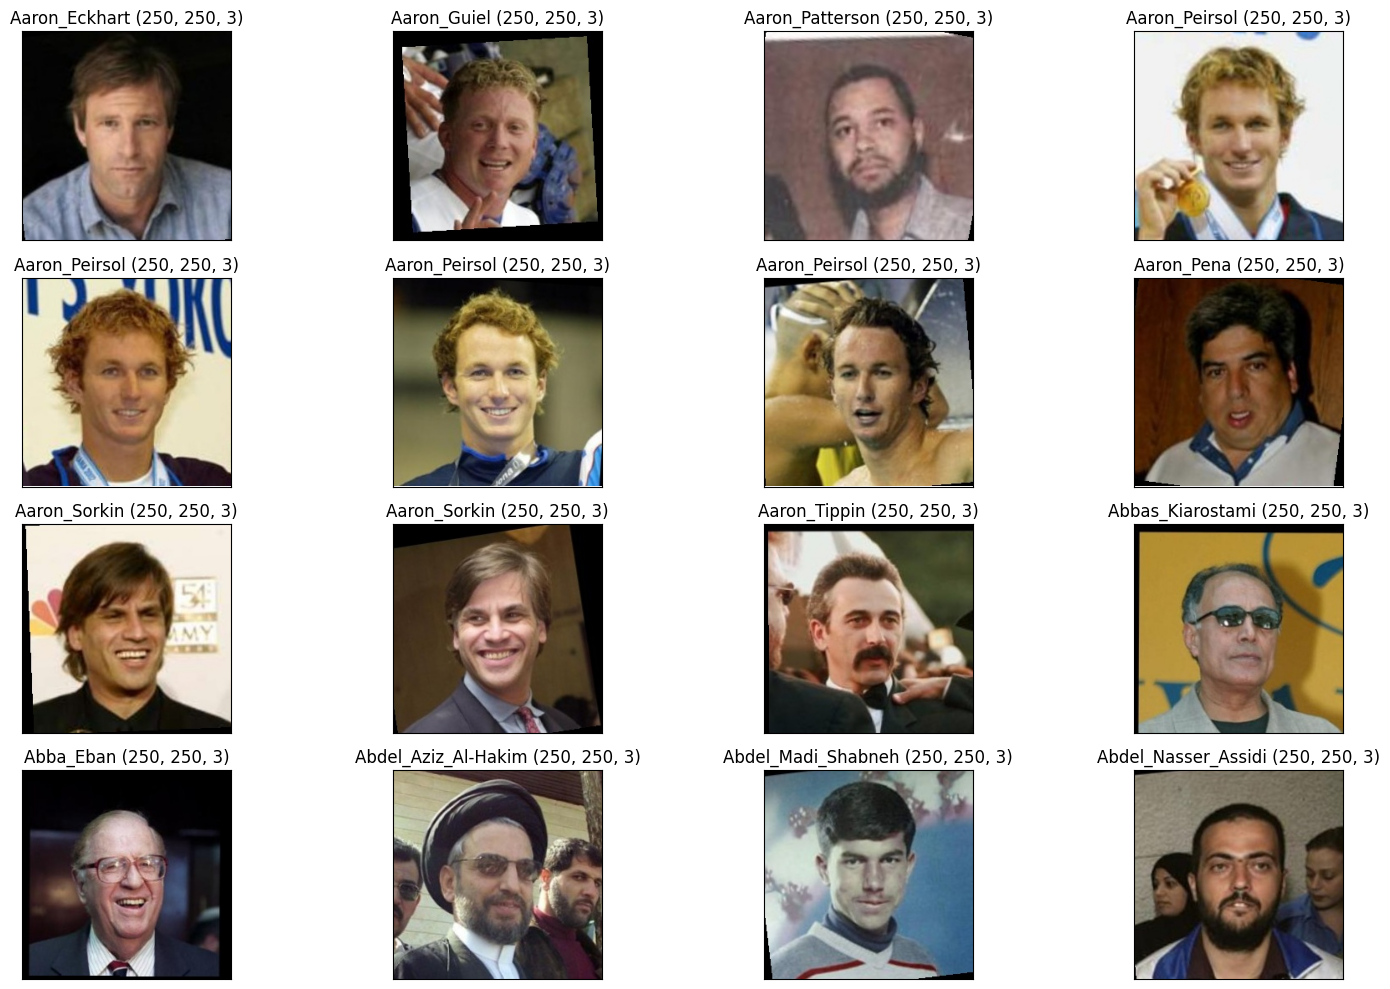

In [3]:
def mostrar_fotos(coleccion, posiciones):
    """
    Muestra imágenes del dataset según posiciones dadas.
    """
    plt.figure(figsize=(16, 10))

    for i, idx in enumerate(posiciones):
        img = plt.imread(coleccion.path.iloc[idx])

        plt.subplot(4, 4, i + 1)
        plt.imshow(img)
        plt.title(f"{coleccion.person.iloc[idx]} {img.shape}")
        plt.xticks([])
        plt.yticks([])

    plt.tight_layout()
    plt.show()


mostrar_fotos(coleccion, list(range(16)))


# P1. Generar vectores característicos

Cada imagen se procesa con `face_recognition`. Si se detecta rostro, se extrae el primer embedding facial. Cada embedding tiene **128 dimensiones**.


## Crear tabla en PostgreSQL

Antes de guardar los embeddings, ejecuta esto en pgAdmin sobre la base `postgres` del contenedor `pgvector`:

```sql
CREATE EXTENSION IF NOT EXISTS vector;

DROP TABLE IF EXISTS face_embeddings;

CREATE TABLE face_embeddings (
    id SERIAL PRIMARY KEY,
    name TEXT,
    path TEXT,
    embedding VECTOR(128)
);
```


In [4]:
import face_recognition
import psycopg2
from pgvector.psycopg2 import register_vector

DB_CONFIG = {
    "host": "localhost",
    "port": 5433,
    "database": "postgres",
    "user": "postgres",
    "password": "123456"
}


def conectar_db():
    """
    Conecta Python con PostgreSQL y registra el tipo vector.
    """
    conn = psycopg2.connect(**DB_CONFIG)
    register_vector(conn)
    return conn


c:\Users\josue\miniconda3\envs\vision\lib\site-packages\face_recognition_models\__init__.py:7: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_filename


In [5]:
def generate_face_embeddings(coleccion, n):
    """
    Genera embeddings faciales para las primeras N imágenes de la colección.
    """
    resultados = []
    limite = min(n, len(coleccion))

    for i in range(limite):
        person = coleccion.iloc[i]["person"]
        filename = coleccion.iloc[i]["path"]

        try:
            image = face_recognition.load_image_file(filename)
            face_encodings = face_recognition.face_encodings(image)

            if face_encodings:
                embedding = face_encodings[0]

                resultados.append({
                    "name": person,
                    "path": filename,
                    "embedding": embedding
                })

                print(f"[OK] {i + 1}/{limite} - {person}")
            else:
                print(f"[SIN ROSTRO] {i + 1}/{limite} - {filename}")

        except Exception as e:
            print(f"[ERROR] {filename}: {e}")

    return resultados


In [6]:
def guardar_embeddings_postgres(embeddings):
    """
    Guarda los embeddings en PostgreSQL.
    """
    conn = conectar_db()
    cur = conn.cursor()

    for item in embeddings:
        cur.execute(
            """
            INSERT INTO face_embeddings (name, path, embedding)
            VALUES (%s, %s, %s)
            """,
            (
                item["name"],
                item["path"],
                item["embedding"].tolist()
            )
        )

    conn.commit()
    cur.close()
    conn.close()

    print("Embeddings guardados correctamente en PostgreSQL.")


## Ejecutar generación de embeddings

Para probar rápido, usa `N = 100`. Para el entregable puedes usar `N = 1000` o más, según el tiempo disponible.


In [7]:
N = 1000

embeddings = generate_face_embeddings(coleccion, N)
print("Cantidad de embeddings generados:", len(embeddings))

guardar_embeddings_postgres(embeddings)


[OK] 1/1000 - Aaron_Eckhart
[OK] 2/1000 - Aaron_Guiel
[OK] 3/1000 - Aaron_Patterson
[OK] 4/1000 - Aaron_Peirsol
[OK] 5/1000 - Aaron_Peirsol
[OK] 6/1000 - Aaron_Peirsol
[OK] 7/1000 - Aaron_Peirsol
[OK] 8/1000 - Aaron_Pena
[OK] 9/1000 - Aaron_Sorkin
[OK] 10/1000 - Aaron_Sorkin
[OK] 11/1000 - Aaron_Tippin
[OK] 12/1000 - Abbas_Kiarostami
[OK] 13/1000 - Abba_Eban
[OK] 14/1000 - Abdel_Aziz_Al-Hakim
[OK] 15/1000 - Abdel_Madi_Shabneh
[OK] 16/1000 - Abdel_Nasser_Assidi
[OK] 17/1000 - Abdel_Nasser_Assidi
[OK] 18/1000 - Abdoulaye_Wade
[OK] 19/1000 - Abdoulaye_Wade
[SIN ROSTRO] 20/1000 - C:\Users\josue\Downloads\archive (1)\lfw-funneled\lfw_funneled\Abdoulaye_Wade\Abdoulaye_Wade_0003.jpg
[OK] 21/1000 - Abdoulaye_Wade
[OK] 22/1000 - Abdulaziz_Kamilov
[OK] 23/1000 - Abdullah
[OK] 24/1000 - Abdullah
[OK] 25/1000 - Abdullah
[OK] 26/1000 - Abdullah
[OK] 27/1000 - Abdullah_Ahmad_Badawi
[OK] 28/1000 - Abdullah_al-Attiyah
[OK] 29/1000 - Abdullah_al-Attiyah
[OK] 30/1000 - Abdullah_al-Attiyah
[OK] 31/1000 -

## Verificar embeddings guardados

Esta consulta comprueba cuántos embeddings se guardaron y que cada vector tenga 128 dimensiones.


In [8]:
conn = conectar_db()
cur = conn.cursor()

cur.execute("SELECT COUNT(*) FROM face_embeddings;")
print("Total de embeddings en PostgreSQL:", cur.fetchone()[0])

cur.execute("SELECT id, name, path, vector_dims(embedding) FROM face_embeddings LIMIT 10;")
for row in cur.fetchall():
    print(row)

cur.close()
conn.close()


Total de embeddings en PostgreSQL: 993
(1, 'Aaron_Eckhart', 'C:\\Users\\josue\\Downloads\\archive (1)\\lfw-funneled\\lfw_funneled\\Aaron_Eckhart\\Aaron_Eckhart_0001.jpg', 128)
(2, 'Aaron_Guiel', 'C:\\Users\\josue\\Downloads\\archive (1)\\lfw-funneled\\lfw_funneled\\Aaron_Guiel\\Aaron_Guiel_0001.jpg', 128)
(3, 'Aaron_Patterson', 'C:\\Users\\josue\\Downloads\\archive (1)\\lfw-funneled\\lfw_funneled\\Aaron_Patterson\\Aaron_Patterson_0001.jpg', 128)
(4, 'Aaron_Peirsol', 'C:\\Users\\josue\\Downloads\\archive (1)\\lfw-funneled\\lfw_funneled\\Aaron_Peirsol\\Aaron_Peirsol_0001.jpg', 128)
(5, 'Aaron_Peirsol', 'C:\\Users\\josue\\Downloads\\archive (1)\\lfw-funneled\\lfw_funneled\\Aaron_Peirsol\\Aaron_Peirsol_0002.jpg', 128)
(6, 'Aaron_Peirsol', 'C:\\Users\\josue\\Downloads\\archive (1)\\lfw-funneled\\lfw_funneled\\Aaron_Peirsol\\Aaron_Peirsol_0003.jpg', 128)
(7, 'Aaron_Peirsol', 'C:\\Users\\josue\\Downloads\\archive (1)\\lfw-funneled\\lfw_funneled\\Aaron_Peirsol\\Aaron_Peirsol_0004.jpg', 128)
(8

# P2. Búsqueda kNN Lineal

En esta parte no se usan índices. La consulta compara el embedding de entrada con todos los embeddings guardados en la tabla.

Se usan dos distancias:

- Distancia euclidiana: `<->`
- Distancia coseno: `<=>`

Coloca una imagen de consulta fuera del dataset, por ejemplo:

```text
C:\Users\josue\Downloads\consulta.jpg
```


In [41]:
import os

QUERY_IMAGE = r"C:\Users\josue\Downloads\consulta.jpg.jpeg"

print("Ruta usada:", QUERY_IMAGE)
print("Existe:", os.path.exists(QUERY_IMAGE))

Ruta usada: C:\Users\josue\Downloads\consulta.jpg.jpeg
Existe: True


In [42]:
def embedding_to_pgvector(embedding):
    """
    Convierte un embedding numpy array a formato string compatible con pgvector.
    Ejemplo: [0.1,0.2,0.3,...]
    """
    return "[" + ",".join(map(str, embedding.tolist())) + "]"


def knn_lineal_euclidiana(query_embedding, k=5):
    """
    Búsqueda kNN lineal usando distancia euclidiana.
    Operador pgvector: <->
    """
    conn = conectar_db()
    cur = conn.cursor()

    query_vector = embedding_to_pgvector(query_embedding)

    start = time.time()

    cur.execute(
        """
        SELECT 
            id,
            name,
            path,
            embedding <-> %s::vector AS distance
        FROM face_embeddings
        ORDER BY embedding <-> %s::vector
        LIMIT %s;
        """,
        (
            query_vector,
            query_vector,
            k
        )
    )

    resultados = cur.fetchall()
    end = time.time()

    cur.close()
    conn.close()

    return resultados, end - start


def knn_lineal_coseno(query_embedding, k=5):
    """
    Búsqueda kNN lineal usando distancia coseno.
    Operador pgvector: <=>
    """
    conn = conectar_db()
    cur = conn.cursor()

    query_vector = embedding_to_pgvector(query_embedding)

    start = time.time()

    cur.execute(
        """
        SELECT 
            id,
            name,
            path,
            embedding <=> %s::vector AS distance
        FROM face_embeddings
        ORDER BY embedding <=> %s::vector
        LIMIT %s;
        """,
        (
            query_vector,
            query_vector,
            k
        )
    )

    resultados = cur.fetchall()
    end = time.time()

    cur.close()
    conn.close()

    return resultados, end - start

In [43]:
K = 5

query_embedding = obtener_embedding_consulta(QUERY_IMAGE)

resultados_euclidiana, tiempo_euclidiana = knn_lineal_euclidiana(query_embedding, K)
resultados_coseno, tiempo_coseno = knn_lineal_coseno(query_embedding, K)

print("===== RESULTADOS KNN LINEAL - DISTANCIA EUCLIDIANA =====")
for r in resultados_euclidiana:
    print(f"ID: {r[0]} | Nombre: {r[1]} | Distancia: {r[3]:.6f} | Path: {r[2]}")

print(f"Tiempo euclidiana: {tiempo_euclidiana:.6f} segundos")

print("\n===== RESULTADOS KNN LINEAL - DISTANCIA COSENO =====")
for r in resultados_coseno:
    print(f"ID: {r[0]} | Nombre: {r[1]} | Distancia: {r[3]:.6f} | Path: {r[2]}")

print(f"Tiempo coseno: {tiempo_coseno:.6f} segundos")

===== RESULTADOS KNN LINEAL - DISTANCIA EUCLIDIANA =====
ID: 267 | Nombre: Alessandra_Cerna | Distancia: 0.495121 | Path: C:\Users\josue\Downloads\archive (1)\lfw-funneled\lfw_funneled\Alessandra_Cerna\Alessandra_Cerna_0001.jpg
ID: 62 | Nombre: Abner_Martinez | Distancia: 0.582080 | Path: C:\Users\josue\Downloads\archive (1)\lfw-funneled\lfw_funneled\Abner_Martinez\Abner_Martinez_0001.jpg
ID: 190 | Nombre: Alberto_Gonzales | Distancia: 0.612831 | Path: C:\Users\josue\Downloads\archive (1)\lfw-funneled\lfw_funneled\Alberto_Gonzales\Alberto_Gonzales_0001.jpg
ID: 973 | Nombre: Art_Lopez | Distancia: 0.639620 | Path: C:\Users\josue\Downloads\archive (1)\lfw-funneled\lfw_funneled\Art_Lopez\Art_Lopez_0001.jpg
ID: 894 | Nombre: Armando_Calderon_Sol | Distancia: 0.643291 | Path: C:\Users\josue\Downloads\archive (1)\lfw-funneled\lfw_funneled\Armando_Calderon_Sol\Armando_Calderon_Sol_0001.jpg
Tiempo euclidiana: 0.000000 segundos

===== RESULTADOS KNN LINEAL - DISTANCIA COSENO =====
ID: 267 | Nom

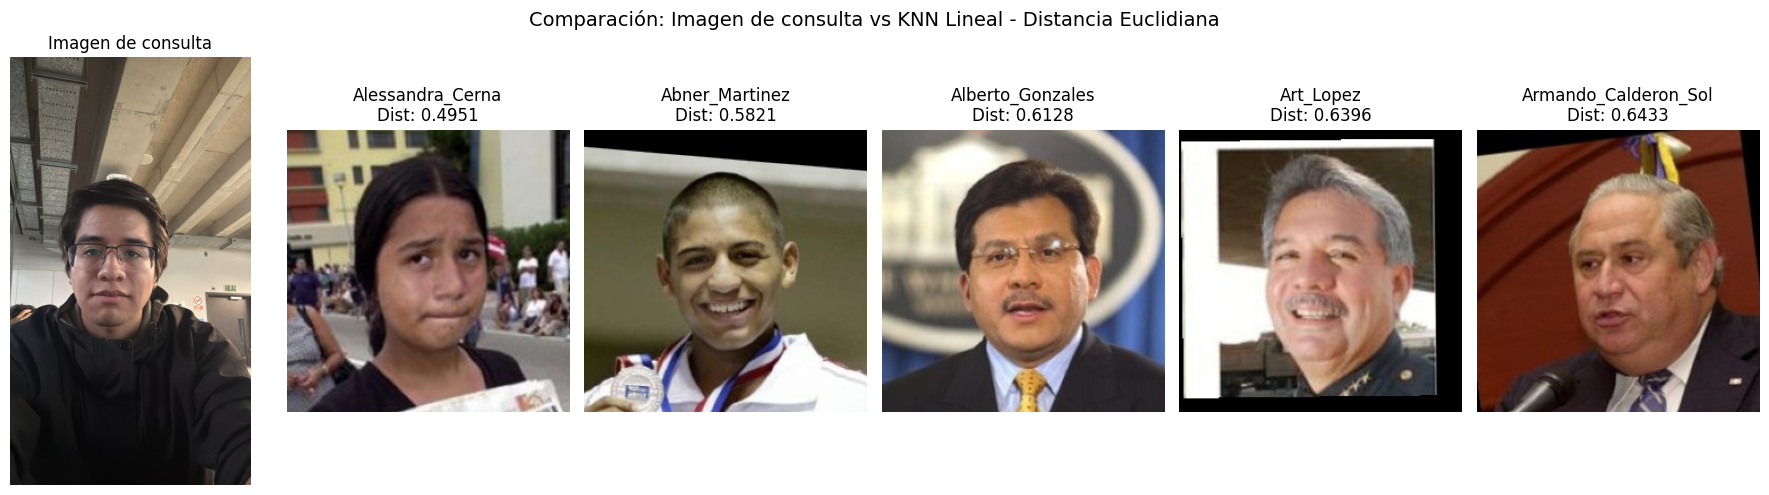

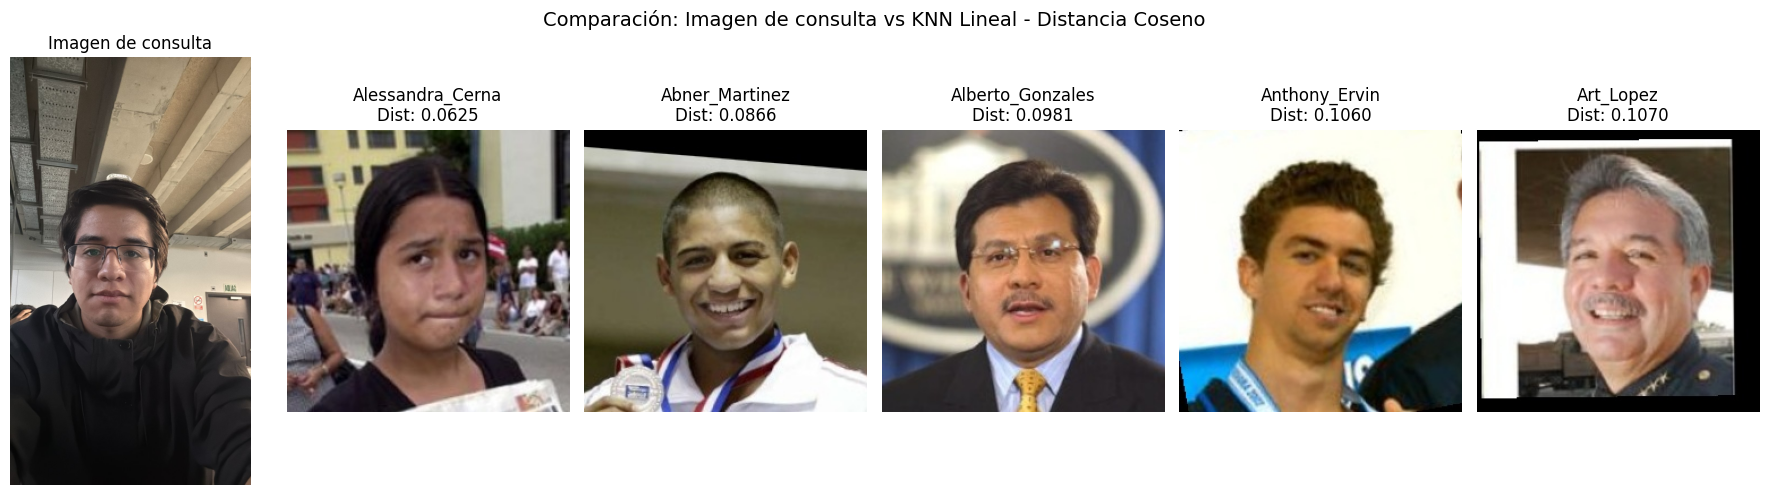

In [44]:
def mostrar_consulta_y_resultados(query_image, resultados, titulo):
    """
    Muestra la imagen de consulta y los resultados recuperados por kNN.
    resultados tiene la forma:
    (id, name, path, distance)
    """
    total_imgs = len(resultados) + 1

    plt.figure(figsize=(18, 5))

    # Imagen de consulta
    img_query = plt.imread(query_image)

    plt.subplot(1, total_imgs, 1)
    plt.imshow(img_query)
    plt.title("Imagen de consulta")
    plt.axis("off")

    # Resultados kNN
    for i, r in enumerate(resultados):
        img_path = r[2]
        name = r[1]
        distance = r[3]

        img = plt.imread(img_path)

        plt.subplot(1, total_imgs, i + 2)
        plt.imshow(img)
        plt.title(f"{name}\nDist: {distance:.4f}")
        plt.axis("off")

    plt.suptitle(titulo, fontsize=14)
    plt.tight_layout()
    plt.show()

mostrar_consulta_y_resultados(
    QUERY_IMAGE,
    resultados_euclidiana,
    "Comparación: Imagen de consulta vs KNN Lineal - Distancia Euclidiana"
)

mostrar_consulta_y_resultados(
    QUERY_IMAGE,
    resultados_coseno,
    "Comparación: Imagen de consulta vs KNN Lineal - Distancia Coseno"
)

## EXPLAIN ANALYZE

Como en P2 todavía no se usan índices, PostgreSQL debería realizar una búsqueda secuencial o un ordenamiento sobre los resultados calculados.


In [45]:
def explain_analyze_knn(query_embedding, operador="<->", k=5):
    """
    Ejecuta EXPLAIN ANALYZE para revisar el plan de ejecución.
    operador puede ser '<->' o '<=>'.
    """
    conn = conectar_db()
    cur = conn.cursor()

    query_vector = embedding_to_pgvector(query_embedding)

    cur.execute(
        f"""
        EXPLAIN ANALYZE
        SELECT 
            id,
            name,
            path,
            embedding {operador} %s::vector AS distance
        FROM face_embeddings
        ORDER BY embedding {operador} %s::vector
        LIMIT %s;
        """,
        (
            query_vector,
            query_vector,
            k
        )
    )

    plan = cur.fetchall()

    cur.close()
    conn.close()

    for row in plan:
        print(row[0])

In [46]:
print("===== EXPLAIN ANALYZE EUCLIDIANA =====")
explain_analyze_knn(query_embedding, "<->", 5)

print("\n===== EXPLAIN ANALYZE COSENO =====")
explain_analyze_knn(query_embedding, "<=>", 5)

===== EXPLAIN ANALYZE EUCLIDIANA =====
Limit  (cost=112.91..112.92 rows=5 width=127) (actual time=0.456..0.457 rows=5 loops=1)
  ->  Sort  (cost=112.91..115.39 rows=993 width=127) (actual time=0.455..0.455 rows=5 loops=1)
        Sort Key: ((embedding <-> '[-0.09139485,0.1368967,0.03383252,0.029723823,-0.012879722,0.034646265,-0.00928095,-0.050371002,0.18306315,-0.037728757,0.27628285,0.020786554,-0.13506334,-0.100948475,-0.060631134,0.17597179,-0.14918074,-0.11329479,-0.08629825,-0.0020210817,-0.008036606,-0.099649146,0.049303927,0.10654104,-0.09677876,-0.33911636,-0.079011135,-0.17325132,0.061694235,-0.08352204,-0.074764684,0.013997396,-0.14350235,-0.050828286,-0.015449703,0.012668386,-0.03476928,-0.045309946,0.2645461,-0.011101056,-0.15659395,0.06313928,0.07764403,0.2885208,0.24859278,0.059500366,0.0056944713,-0.016955227,0.15753433,-0.2581972,0.120385475,0.10990886,0.15912905,0.076942116,0.094269544,-0.09027669,0.0051338226,0.12334174,-0.13391802,0.058057185,-0.0323198,-0.016854279

## P3. Búsqueda kNN usando PgVector

In [47]:
def ejecutar_sql(sql):
    conn = conectar_db()
    cur = conn.cursor()
    cur.execute(sql)
    conn.commit()
    cur.close()
    conn.close()
    print("SQL ejecutado correctamente.")

In [48]:
sql_ivf_l2 = """
DROP INDEX IF EXISTS face_embedding_ivfflat_l2_idx;

CREATE INDEX face_embedding_ivfflat_l2_idx
ON face_embeddings
USING ivfflat (embedding vector_l2_ops)
WITH (lists = 100);
"""

ejecutar_sql(sql_ivf_l2)

SQL ejecutado correctamente.


In [49]:
ejecutar_sql("ANALYZE face_embeddings;")

SQL ejecutado correctamente.


## IVFFLat

In [ ]:
print("===== EXPLAIN ANALYZE EUCLIDIANA =====")
explain_analyze_knn(query_embedding, "<->", 5)

print("\n===== EXPLAIN ANALYZE COSENO =====")
explain_analyze_knn(query_embedding, "<=>", 5)

===== EXPLAIN ANALYZE EUCLIDIANA =====
Limit  (cost=112.91..112.92 rows=5 width=127) (actual time=0.456..0.457 rows=5 loops=1)
  ->  Sort  (cost=112.91..115.39 rows=993 width=127) (actual time=0.455..0.455 rows=5 loops=1)
        Sort Key: ((embedding <-> '[-0.09139485,0.1368967,0.03383252,0.029723823,-0.012879722,0.034646265,-0.00928095,-0.050371002,0.18306315,-0.037728757,0.27628285,0.020786554,-0.13506334,-0.100948475,-0.060631134,0.17597179,-0.14918074,-0.11329479,-0.08629825,-0.0020210817,-0.008036606,-0.099649146,0.049303927,0.10654104,-0.09677876,-0.33911636,-0.079011135,-0.17325132,0.061694235,-0.08352204,-0.074764684,0.013997396,-0.14350235,-0.050828286,-0.015449703,0.012668386,-0.03476928,-0.045309946,0.2645461,-0.011101056,-0.15659395,0.06313928,0.07764403,0.2885208,0.24859278,0.059500366,0.0056944713,-0.016955227,0.15753433,-0.2581972,0.120385475,0.10990886,0.15912905,0.076942116,0.094269544,-0.09027669,0.0051338226,0.12334174,-0.13391802,0.058057185,-0.0323198,-0.016854279

In [50]:
def knn_ivfflat_euclidiana(query_embedding, k=5, probes=10):
    conn = conectar_db()
    cur = conn.cursor()

    query_vector = embedding_to_pgvector(query_embedding)

    cur.execute(f"SET ivfflat.probes = {probes};")

    start = time.time()

    cur.execute(
        """
        SELECT 
            id,
            name,
            path,
            embedding <-> %s::vector AS distance
        FROM face_embeddings
        ORDER BY embedding <-> %s::vector
        LIMIT %s;
        """,
        (
            query_vector,
            query_vector,
            k
        )
    )

    resultados = cur.fetchall()
    end = time.time()

    cur.close()
    conn.close()

    return resultados, end - start

In [51]:
resultados_ivf_l2, tiempo_ivf_l2 = knn_ivfflat_euclidiana(query_embedding, k=5, probes=10)

print("===== KNN IVFFLAT - EUCLIDIANA =====")
for r in resultados_ivf_l2:
    print(f"ID: {r[0]} | Nombre: {r[1]} | Distancia: {r[3]:.6f} | Path: {r[2]}")

print(f"Tiempo IVFFlat euclidiana: {tiempo_ivf_l2:.6f} segundos")

===== KNN IVFFLAT - EUCLIDIANA =====
ID: 267 | Nombre: Alessandra_Cerna | Distancia: 0.495121 | Path: C:\Users\josue\Downloads\archive (1)\lfw-funneled\lfw_funneled\Alessandra_Cerna\Alessandra_Cerna_0001.jpg
ID: 62 | Nombre: Abner_Martinez | Distancia: 0.582080 | Path: C:\Users\josue\Downloads\archive (1)\lfw-funneled\lfw_funneled\Abner_Martinez\Abner_Martinez_0001.jpg
ID: 190 | Nombre: Alberto_Gonzales | Distancia: 0.612831 | Path: C:\Users\josue\Downloads\archive (1)\lfw-funneled\lfw_funneled\Alberto_Gonzales\Alberto_Gonzales_0001.jpg
ID: 973 | Nombre: Art_Lopez | Distancia: 0.639620 | Path: C:\Users\josue\Downloads\archive (1)\lfw-funneled\lfw_funneled\Art_Lopez\Art_Lopez_0001.jpg
ID: 894 | Nombre: Armando_Calderon_Sol | Distancia: 0.643291 | Path: C:\Users\josue\Downloads\archive (1)\lfw-funneled\lfw_funneled\Armando_Calderon_Sol\Armando_Calderon_Sol_0001.jpg
Tiempo IVFFlat euclidiana: 0.000000 segundos


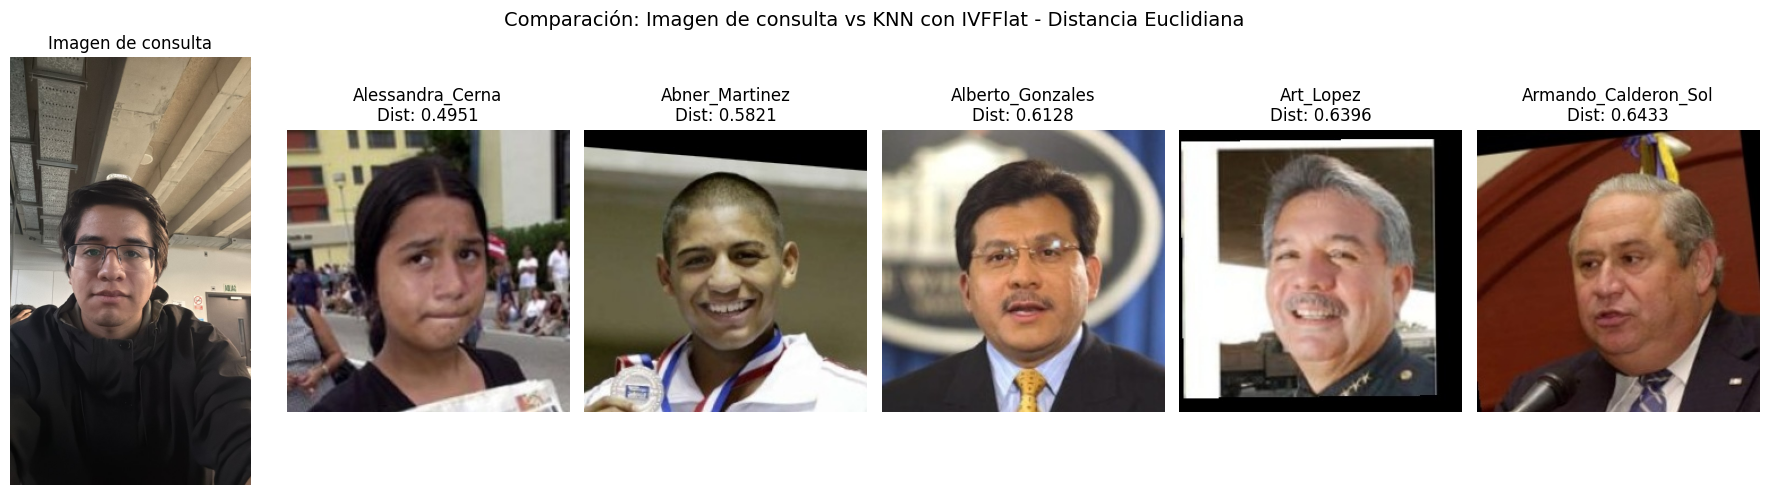

In [52]:
mostrar_consulta_y_resultados(
    QUERY_IMAGE,
    resultados_ivf_l2,
    "Comparación: Imagen de consulta vs KNN con IVFFlat - Distancia Euclidiana"
)

EXPLAIN ANALYZE para IVFFlat euclidiano

In [53]:
def explain_analyze_ivfflat(query_embedding, operador="<->", k=5, probes=10):
    conn = conectar_db()
    cur = conn.cursor()

    query_vector = embedding_to_pgvector(query_embedding)

    cur.execute(f"SET ivfflat.probes = {probes};")

    cur.execute(
        f"""
        EXPLAIN ANALYZE
        SELECT 
            id,
            name,
            path,
            embedding {operador} %s::vector AS distance
        FROM face_embeddings
        ORDER BY embedding {operador} %s::vector
        LIMIT %s;
        """,
        (
            query_vector,
            query_vector,
            k
        )
    )

    plan = cur.fetchall()

    cur.close()
    conn.close()

    for row in plan:
        print(row[0])

In [54]:
print("===== EXPLAIN ANALYZE IVFFLAT EUCLIDIANA =====")
explain_analyze_ivfflat(query_embedding, "<->", k=5, probes=10)

===== EXPLAIN ANALYZE IVFFLAT EUCLIDIANA =====
Limit  (cost=33.24..34.53 rows=5 width=127) (actual time=0.079..0.094 rows=5 loops=1)
  ->  Index Scan using face_embedding_ivfflat_l2_idx on face_embeddings  (cost=33.24..288.72 rows=993 width=127) (actual time=0.079..0.093 rows=5 loops=1)
        Order By: (embedding <-> '[-0.09139485,0.1368967,0.03383252,0.029723823,-0.012879722,0.034646265,-0.00928095,-0.050371002,0.18306315,-0.037728757,0.27628285,0.020786554,-0.13506334,-0.100948475,-0.060631134,0.17597179,-0.14918074,-0.11329479,-0.08629825,-0.0020210817,-0.008036606,-0.099649146,0.049303927,0.10654104,-0.09677876,-0.33911636,-0.079011135,-0.17325132,0.061694235,-0.08352204,-0.074764684,0.013997396,-0.14350235,-0.050828286,-0.015449703,0.012668386,-0.03476928,-0.045309946,0.2645461,-0.011101056,-0.15659395,0.06313928,0.07764403,0.2885208,0.24859278,0.059500366,0.0056944713,-0.016955227,0.15753433,-0.2581972,0.120385475,0.10990886,0.15912905,0.076942116,0.094269544,-0.09027669,0.0051

 4. Crear índice IVFFlat coseno

In [55]:
sql_ivf_cosine = """
DROP INDEX IF EXISTS face_embedding_ivfflat_cosine_idx;

CREATE INDEX face_embedding_ivfflat_cosine_idx
ON face_embeddings
USING ivfflat (embedding vector_cosine_ops)
WITH (lists = 100);
"""

ejecutar_sql(sql_ivf_cosine)
ejecutar_sql("ANALYZE face_embeddings;")

SQL ejecutado correctamente.
SQL ejecutado correctamente.


5. Función kNN IVFFlat coseno

In [56]:
def knn_ivfflat_coseno(query_embedding, k=5, probes=10):
    conn = conectar_db()
    cur = conn.cursor()

    query_vector = embedding_to_pgvector(query_embedding)

    cur.execute(f"SET ivfflat.probes = {probes};")

    start = time.time()

    cur.execute(
        """
        SELECT 
            id,
            name,
            path,
            embedding <=> %s::vector AS distance
        FROM face_embeddings
        ORDER BY embedding <=> %s::vector
        LIMIT %s;
        """,
        (
            query_vector,
            query_vector,
            k
        )
    )

    resultados = cur.fetchall()
    end = time.time()

    cur.close()
    conn.close()

    return resultados, end - start

In [57]:
resultados_ivf_coseno, tiempo_ivf_coseno = knn_ivfflat_coseno(query_embedding, k=5, probes=10)

print("===== KNN IVFFLAT - COSENO =====")
for r in resultados_ivf_coseno:
    print(f"ID: {r[0]} | Nombre: {r[1]} | Distancia: {r[3]:.6f} | Path: {r[2]}")

print(f"Tiempo IVFFlat coseno: {tiempo_ivf_coseno:.6f} segundos")

===== KNN IVFFLAT - COSENO =====
ID: 267 | Nombre: Alessandra_Cerna | Distancia: 0.062490 | Path: C:\Users\josue\Downloads\archive (1)\lfw-funneled\lfw_funneled\Alessandra_Cerna\Alessandra_Cerna_0001.jpg
ID: 62 | Nombre: Abner_Martinez | Distancia: 0.086580 | Path: C:\Users\josue\Downloads\archive (1)\lfw-funneled\lfw_funneled\Abner_Martinez\Abner_Martinez_0001.jpg
ID: 190 | Nombre: Alberto_Gonzales | Distancia: 0.098063 | Path: C:\Users\josue\Downloads\archive (1)\lfw-funneled\lfw_funneled\Alberto_Gonzales\Alberto_Gonzales_0001.jpg
ID: 973 | Nombre: Art_Lopez | Distancia: 0.107013 | Path: C:\Users\josue\Downloads\archive (1)\lfw-funneled\lfw_funneled\Art_Lopez\Art_Lopez_0001.jpg
ID: 755 | Nombre: Anthony_Pico | Distancia: 0.109905 | Path: C:\Users\josue\Downloads\archive (1)\lfw-funneled\lfw_funneled\Anthony_Pico\Anthony_Pico_0001.jpg
Tiempo IVFFlat coseno: 0.000000 segundos


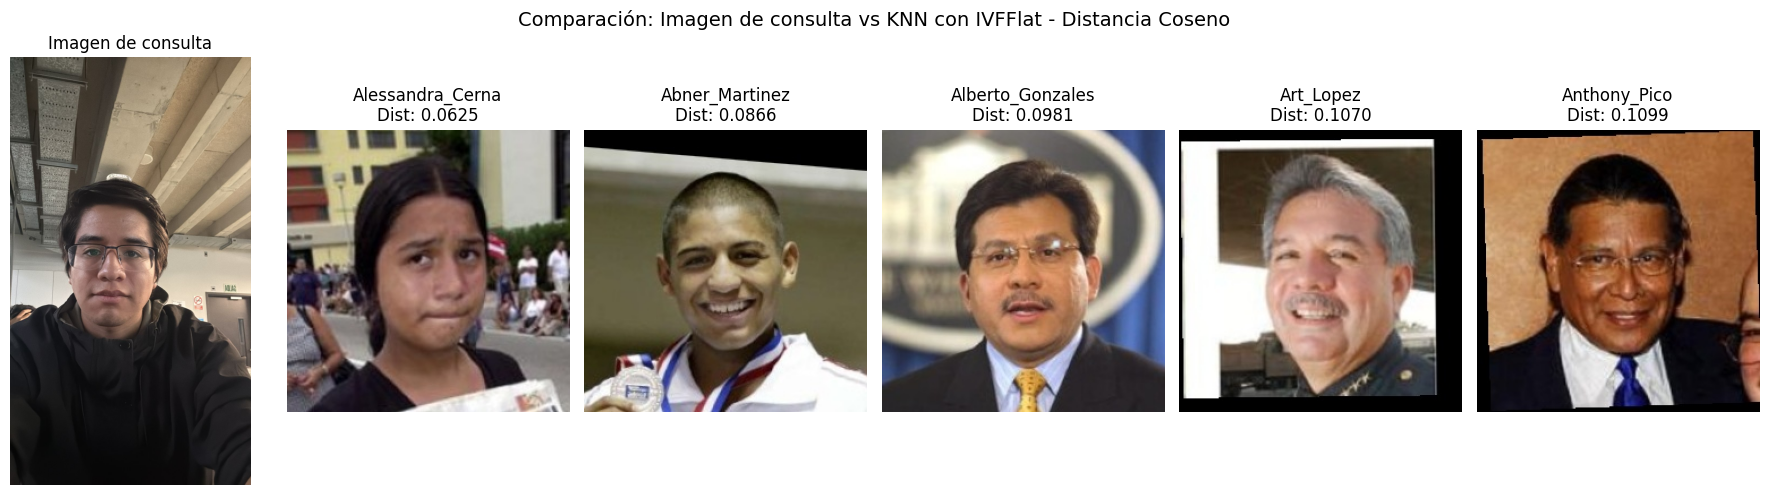

In [58]:
mostrar_consulta_y_resultados(
    QUERY_IMAGE,
    resultados_ivf_coseno,
    "Comparación: Imagen de consulta vs KNN con IVFFlat - Distancia Coseno"
)

In [59]:
print("===== EXPLAIN ANALYZE IVFFLAT COSENO =====")
explain_analyze_ivfflat(query_embedding, "<=>", k=5, probes=10)

===== EXPLAIN ANALYZE IVFFLAT COSENO =====
Limit  (cost=33.24..34.53 rows=5 width=127) (actual time=0.076..0.092 rows=5 loops=1)
  ->  Index Scan using face_embedding_ivfflat_cosine_idx on face_embeddings  (cost=33.24..288.72 rows=993 width=127) (actual time=0.076..0.091 rows=5 loops=1)
        Order By: (embedding <=> '[-0.09139485,0.1368967,0.03383252,0.029723823,-0.012879722,0.034646265,-0.00928095,-0.050371002,0.18306315,-0.037728757,0.27628285,0.020786554,-0.13506334,-0.100948475,-0.060631134,0.17597179,-0.14918074,-0.11329479,-0.08629825,-0.0020210817,-0.008036606,-0.099649146,0.049303927,0.10654104,-0.09677876,-0.33911636,-0.079011135,-0.17325132,0.061694235,-0.08352204,-0.074764684,0.013997396,-0.14350235,-0.050828286,-0.015449703,0.012668386,-0.03476928,-0.045309946,0.2645461,-0.011101056,-0.15659395,0.06313928,0.07764403,0.2885208,0.24859278,0.059500366,0.0056944713,-0.016955227,0.15753433,-0.2581972,0.120385475,0.10990886,0.15912905,0.076942116,0.094269544,-0.09027669,0.0051

## HNSW